```datar``` allows applying plotnine's ggplot into the processing pipeline

In [1]:
import datar.all as dr
from datar import f
import pandas as pd
import plotnine as pln

from pathlib import Path

# Get the path object pointing to the ``notebooks`` directory that contains *.csv files 
data_dir = next(Path("/home").rglob("*/notebooks/*.csv")).parent

In [2]:
tb_baseball = (
    pd.read_csv(data_dir/"baseball.csv")
    >> dr.select(f.Name, f.Position, f.Height, f.Weight)
    >> dr.mutate(Position = dr.as_factor(f.Position))
)

print(tb_baseball >> dr.slice_head(4))

              Name       Position  Height  Weight
             <str>     <category> <int64> <int64>
0    Adam_Donachie        Catcher      74     180
1        Paul_Bako        Catcher      74     215
2  Ramon_Hernandez        Catcher      72     210
3     Kevin_Millar  First_Baseman      72     210


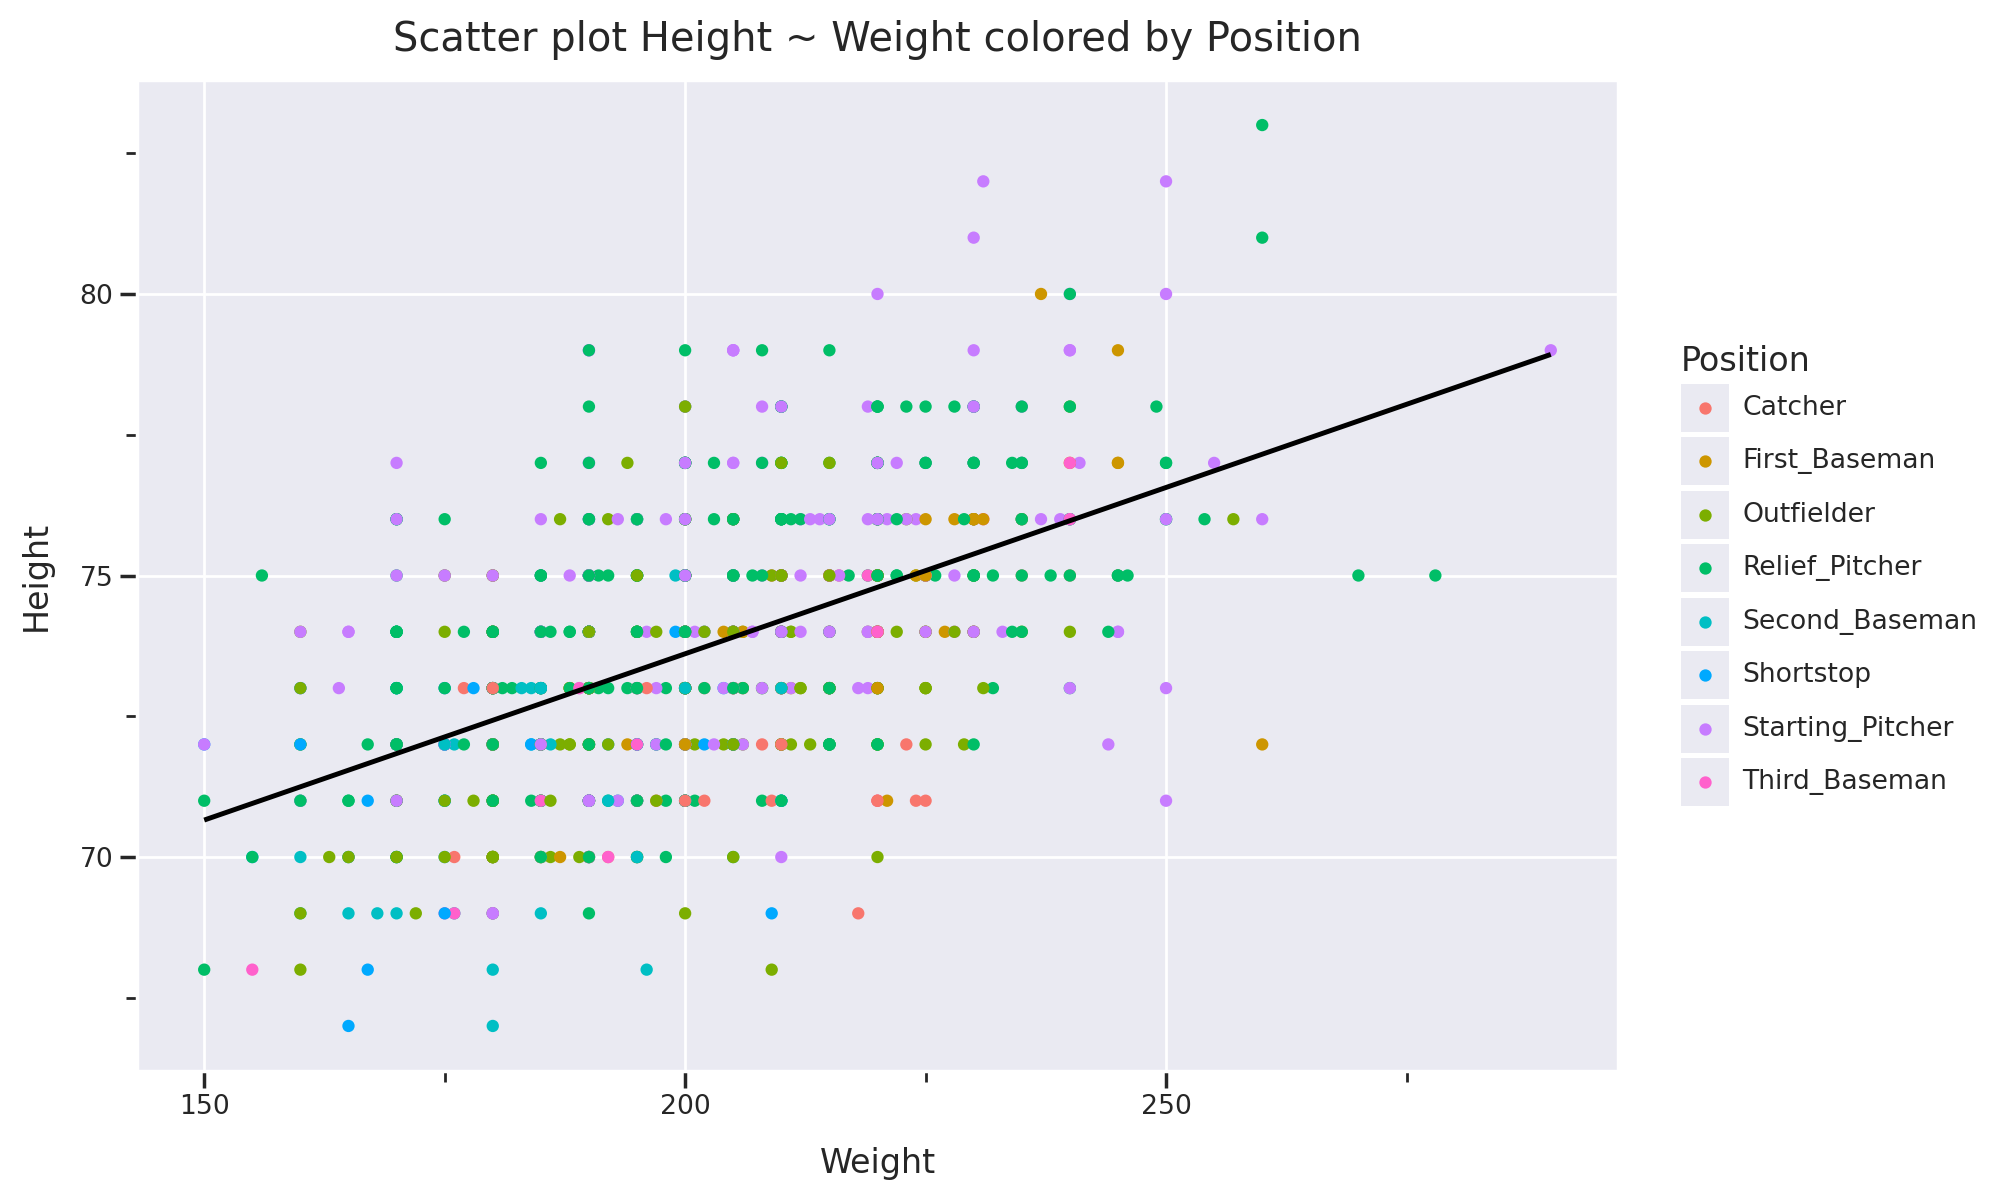

In [5]:
##----------------------------------------------------------------------##
##           Use plotnine to draw scatter plot Height ~ Weight          ##
##----------------------------------------------------------------------##

(
    tb_baseball
    >> pln.ggplot()
    + pln.theme_seaborn()
    + pln.geom_point(pln.aes(x="Weight", y="Height", color="Position"))
    + pln.geom_smooth(pln.aes(x="Weight", y="Height"), method="lm", se=False, color="black")
    + pln.ggtitle("Scatter plot Height ~ Weight colored by Position")
    + pln.theme(figure_size=(10, 6)) # width=10, height=6
).show()

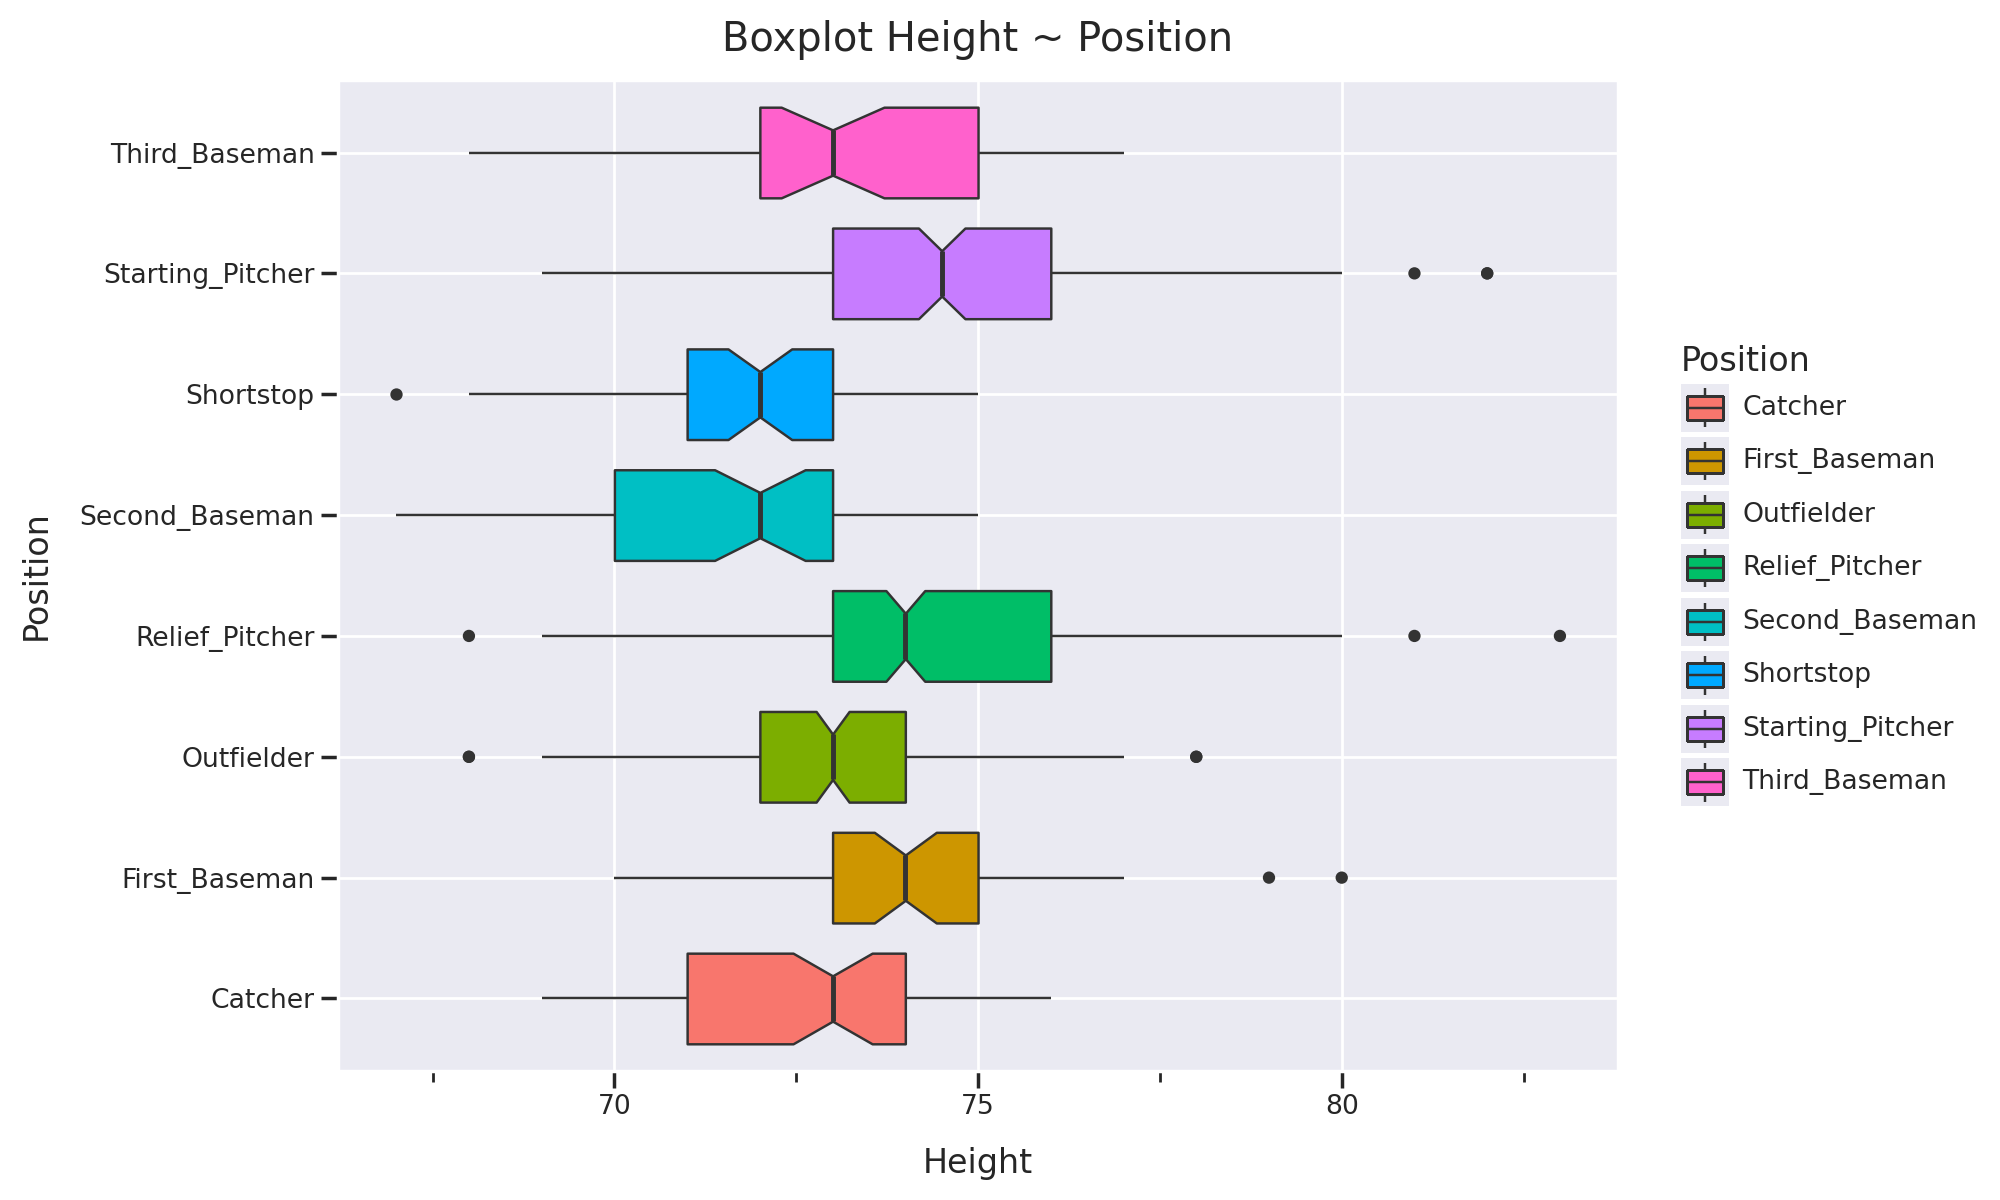

In [6]:
##---------------------------------------------------------------------##
##           Use plotnine to draw boxplot Height ~ Position            ##
##---------------------------------------------------------------------##

(
    tb_baseball
    >> pln.ggplot()
    + pln.theme_seaborn()
    + pln.geom_boxplot(pln.aes(x="Position", y="Height", fill="Position"), notch=True)
    + pln.coord_flip()
    + pln.ggtitle("Boxplot Height ~ Position")
    + pln.theme(figure_size=(10, 6)) # width=10, height=6
).show()